# 02 — Regression Algorithms

Regression predicts a **continuous** target. This notebook walks through the
regression algorithms you'll use most often with scikit-learn, in increasing
order of flexibility: a straight line, a regularized line, a curve, a tree,
a forest of trees, a sequence of boosted trees, and a margin-based method.

For every algorithm: theory → sklearn implementation → evaluation →
visualization. We use the built-in **diabetes** dataset (bundled with
sklearn, no download required) as the shared benchmark, plus small synthetic
1D datasets whenever a visual intuition is clearer than a real dataset.

**Algorithms covered:**
1. Linear Regression
2. Polynomial Regression
3. Regularization: Ridge, Lasso, ElasticNet
4. Decision Tree Regressor
5. Random Forest Regressor
6. Gradient Boosting Regressor
7. Support Vector Regression (SVR)
8. Side-by-side model comparison

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

sns.set_theme(style="whitegrid")
rng = np.random.default_rng(1)

diabetes = load_diabetes()
X, y = diabetes.data, diabetes.target
feature_names = diabetes.feature_names
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

results = {}  # collect (rmse, r2) per model for the final comparison

def evaluate(name, model, X_tr=X_train, X_te=X_test, y_tr=y_train, y_te=y_test):
    model.fit(X_tr, y_tr)
    pred = model.predict(X_te)
    rmse = np.sqrt(mean_squared_error(y_te, pred))
    r2 = r2_score(y_te, pred)
    results[name] = (rmse, r2)
    print(f"{name:>22}:  RMSE = {rmse:6.2f}   R2 = {r2:.3f}")
    return model, pred

## 1. Linear Regression

**Theory.** Linear regression fits a hyperplane `ŷ = w·x + b` that minimizes
the sum of squared residuals (Ordinary Least Squares). It assumes:
- a roughly linear relationship between features and target,
- residuals are independent, homoscedastic (constant variance), and roughly normal.

**Pros:** simple, fast, interpretable coefficients. **Cons:** can't capture
non-linear relationships, sensitive to multicollinearity and outliers.

In [2]:
from sklearn.linear_model import LinearRegression

lin_reg, lin_pred = evaluate("Linear Regression", LinearRegression())

     Linear Regression:  RMSE =  54.70   R2 = 0.438


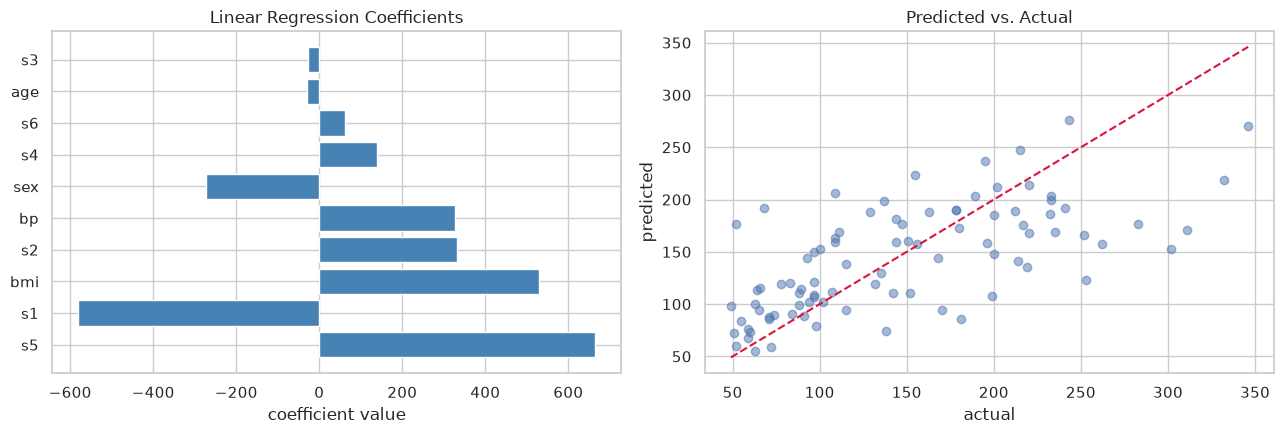

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

coef_order = np.argsort(np.abs(lin_reg.coef_))[::-1]
axes[0].barh(np.array(feature_names)[coef_order], lin_reg.coef_[coef_order], color="steelblue")
axes[0].set_title("Linear Regression Coefficients")
axes[0].set_xlabel("coefficient value")

axes[1].scatter(y_test, lin_pred, alpha=0.5)
lims = [y_test.min(), y_test.max()]
axes[1].plot(lims, lims, color="crimson", linestyle="--")
axes[1].set_xlabel("actual")
axes[1].set_ylabel("predicted")
axes[1].set_title("Predicted vs. Actual")

plt.tight_layout()
plt.show()

Coefficients tell you both direction and (once features are scaled)
relative importance — `bmi` and `s5` push the prediction up the most here.

## 2. Polynomial Regression

**Theory.** Still a *linear* model in its coefficients, but we first expand
the features into polynomial terms (`x, x², x³, ...`), letting a straight-line
model fit curved relationships. Great illustration of the bias-variance
tradeoff from `00_foundations`: too low a degree underfits, too high overfits.

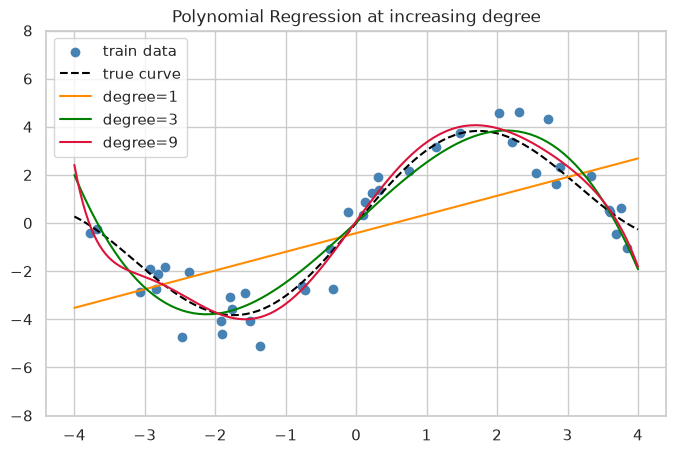

In [4]:
# 1D synthetic curve so the fit is easy to see
def true_curve(x):
    return 3 * np.sin(x) + 0.5 * x

x_1d = np.sort(rng.uniform(-4, 4, 60))
y_1d = true_curve(x_1d) + rng.normal(scale=1.0, size=60)
x_1d_train, x_1d_test, y_1d_train, y_1d_test = train_test_split(x_1d, y_1d, test_size=0.3, random_state=1)

from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

x_plot = np.linspace(-4, 4, 200)
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(x_1d_train, y_1d_train, label="train data", color="steelblue")
ax.plot(x_plot, true_curve(x_plot), color="black", linestyle="--", label="true curve")

for degree, color in zip([1, 3, 9], ["darkorange", "green", "crimson"]):
    model = make_pipeline(PolynomialFeatures(degree), LinearRegression())
    model.fit(x_1d_train.reshape(-1, 1), y_1d_train)
    ax.plot(x_plot, model.predict(x_plot.reshape(-1, 1)), color=color, label=f"degree={degree}")

ax.set_ylim(-8, 8)
ax.legend()
ax.set_title("Polynomial Regression at increasing degree")
plt.show()

## 3. Regularization: Ridge, Lasso, ElasticNet

**Theory.** Regularization adds a penalty on coefficient size to the loss
function, trading a little training bias for a lot less variance:

- **Ridge (L2):** penalty `α * Σw²` — shrinks all coefficients smoothly toward zero, rarely to exactly zero.
- **Lasso (L1):** penalty `α * Σ|w|` — can shrink coefficients *exactly* to zero, performing automatic feature selection.
- **ElasticNet:** a weighted mix of L1 and L2 — feature selection like Lasso, with Ridge's stability when features are correlated.

`α` controls the strength of the penalty: `α=0` recovers plain linear regression, larger `α` means more shrinkage.

In [5]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.preprocessing import StandardScaler

# Scale first: regularization penalizes coefficient magnitude, so features must be on comparable scales
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

evaluate("Ridge (alpha=1.0)", Ridge(alpha=1.0), X_train_s, X_test_s)
evaluate("Lasso (alpha=0.1)", Lasso(alpha=0.1), X_train_s, X_test_s)
evaluate("ElasticNet (alpha=0.1)", ElasticNet(alpha=0.1, l1_ratio=0.5), X_train_s, X_test_s)

     Ridge (alpha=1.0):  RMSE =  54.81   R2 = 0.436
     Lasso (alpha=0.1):  RMSE =  54.86   R2 = 0.435
ElasticNet (alpha=0.1):  RMSE =  55.02   R2 = 0.432


(ElasticNet(alpha=0.1),
 array([118.64578495, 106.99679809, 186.87914508,  68.97088635,
        169.68728475, 188.29016421, 216.60938095, 123.33908535,
        154.62750061, 129.3352914 , 209.48575039, 198.58834918,
         91.83457835,  74.65862344, 231.76590811, 204.04114657,
        173.54749771, 103.18611959, 118.71252881, 166.82318911,
        185.93490471,  89.6193433 , 143.14366806, 105.07524034,
         94.21798771, 208.24000545,  92.49435089, 173.03480932,
        126.44872771, 180.27040107, 156.41670468, 138.64132821,
        191.12851075,  92.71073543, 160.6470817 , 188.08741393,
        107.53649028, 244.79088572, 172.02946993, 184.42000777,
        156.80962762, 174.01842159, 115.26362352, 121.12950959,
        137.32230718, 200.95126776, 150.60594618, 141.71939684,
        188.33570306, 198.90908109,  67.665835  , 162.53824525,
        104.253344  , 144.1384127 , 184.97751836, 122.67621648,
        157.25874738,  91.73282018,  62.23145059,  84.15357682,
         99.1956

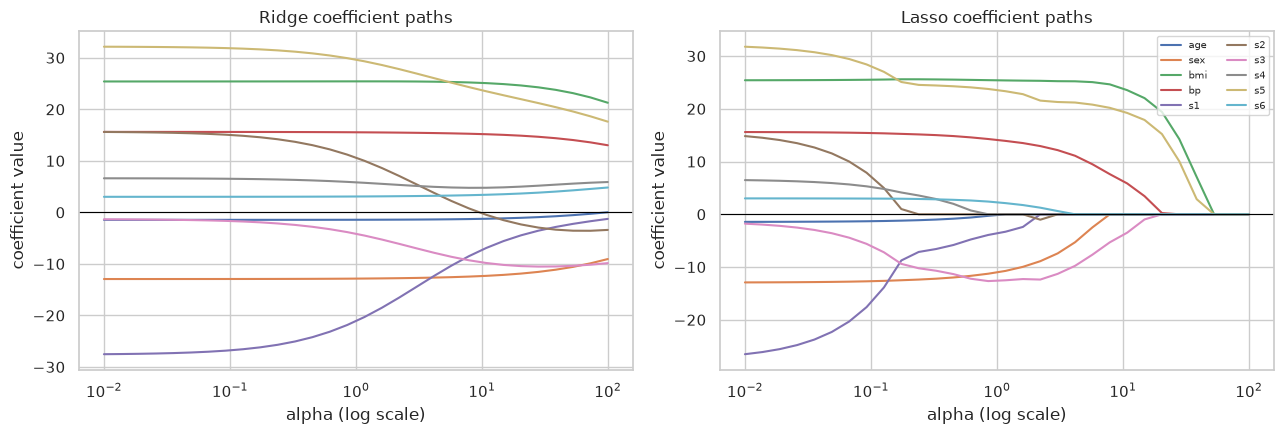

In [6]:
alphas = np.logspace(-2, 2, 30)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for name, Model in [("Ridge", Ridge), ("Lasso", Lasso)]:
    coefs = []
    for a in alphas:
        m = Model(alpha=a, max_iter=10000) if name == "Lasso" else Model(alpha=a)
        m.fit(X_train_s, y_train)
        coefs.append(m.coef_)
    coefs = np.array(coefs)
    ax = axes[0] if name == "Ridge" else axes[1]
    for i in range(coefs.shape[1]):
        ax.plot(alphas, coefs[:, i], label=feature_names[i])
    ax.set_xscale("log")
    ax.set_xlabel("alpha (log scale)")
    ax.set_ylabel("coefficient value")
    ax.set_title(f"{name} coefficient paths")
    ax.axhline(0, color="black", linewidth=0.8)
axes[1].legend(fontsize=7, loc="upper right", ncol=2)
plt.tight_layout()
plt.show()

Watch the right panel (Lasso): as `alpha` grows, coefficients don't just
shrink — several flatten to *exactly* zero and stay there, effectively
dropping those features. Ridge (left) shrinks everything smoothly but rarely
hits exact zero.

## 4. Decision Tree Regressor

**Theory.** A decision tree recursively splits the feature space into regions
that minimize prediction error (typically MSE) within each region, then
predicts the average target value of the training points in a leaf. No
assumption of linearity at all — but a single deep tree memorizes the
training data easily (high variance).

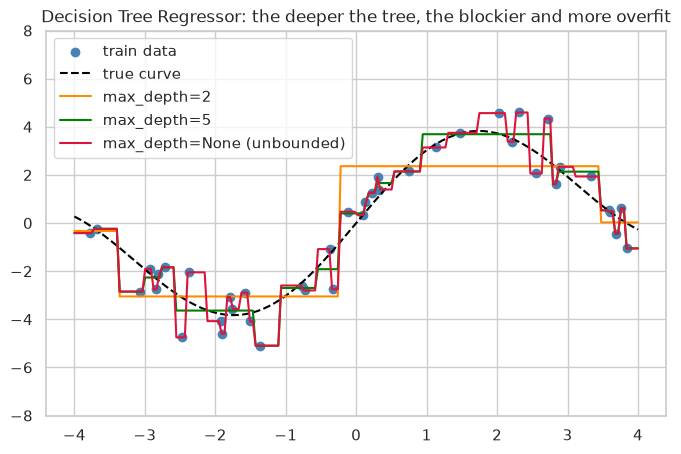

In [7]:
from sklearn.tree import DecisionTreeRegressor, plot_tree

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(x_1d_train, y_1d_train, label="train data", color="steelblue")
ax.plot(x_plot, true_curve(x_plot), color="black", linestyle="--", label="true curve")

for depth, color in zip([2, 5, None], ["darkorange", "green", "crimson"]):
    tree = DecisionTreeRegressor(max_depth=depth, random_state=1)
    tree.fit(x_1d_train.reshape(-1, 1), y_1d_train)
    label = f"max_depth={depth}" if depth else "max_depth=None (unbounded)"
    ax.plot(x_plot, tree.predict(x_plot.reshape(-1, 1)), color=color, label=label)

ax.set_ylim(-8, 8)
ax.legend()
ax.set_title("Decision Tree Regressor: the deeper the tree, the blockier and more overfit")
plt.show()

Decision Tree (depth=4):  RMSE =  70.36   R2 = 0.071


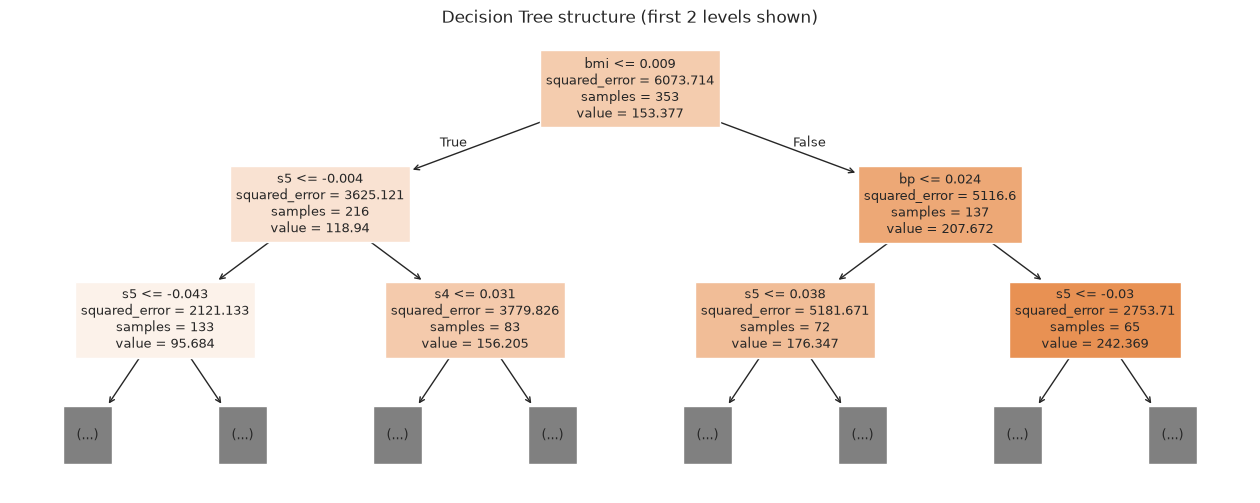

In [8]:
tree_model, tree_pred = evaluate("Decision Tree (depth=4)", DecisionTreeRegressor(max_depth=4, random_state=1))

plt.figure(figsize=(16, 6))
plot_tree(tree_model, feature_names=feature_names, filled=True, max_depth=2, fontsize=9)
plt.title("Decision Tree structure (first 2 levels shown)")
plt.show()

Notice the step-function shape in the 1D plot — trees predict a constant
value within each region, so predictions look "blocky" rather than smooth.
An unbounded tree (`max_depth=None`) fits every training point almost
exactly: a textbook case of overfitting.

## 5. Random Forest Regressor

**Theory.** An **ensemble** of many decision trees, each trained on a
bootstrap sample of the data (bagging) and a random subset of features at
each split. Averaging many high-variance, low-bias trees cancels out much of
that variance while keeping the low bias — usually a big accuracy jump over
a single tree.

In [9]:
from sklearn.ensemble import RandomForestRegressor

rf_model, rf_pred = evaluate("Random Forest", RandomForestRegressor(n_estimators=300, random_state=1))

         Random Forest:  RMSE =  61.07   R2 = 0.300


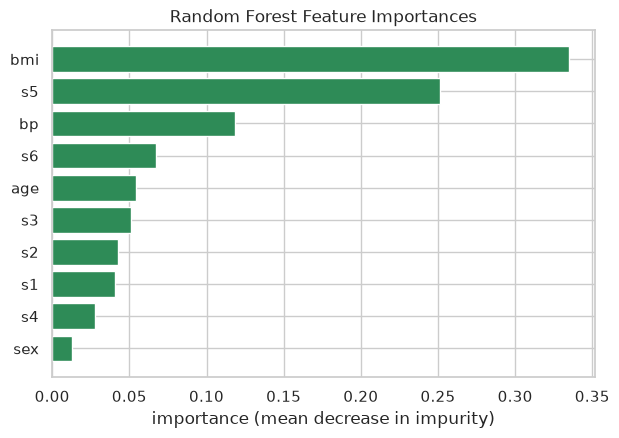

In [10]:
importances = rf_model.feature_importances_
order = np.argsort(importances)[::-1]

plt.figure(figsize=(7, 4.5))
plt.barh(np.array(feature_names)[order], importances[order], color="seagreen")
plt.gca().invert_yaxis()
plt.xlabel("importance (mean decrease in impurity)")
plt.title("Random Forest Feature Importances")
plt.show()

## 6. Gradient Boosting Regressor

**Theory.** Instead of averaging independent trees, boosting builds trees
**sequentially**: each new (typically shallow) tree is trained to predict the
*residual errors* of the ensemble so far, and its (scaled) predictions are
added on top. This often reaches higher accuracy than bagging, at the cost of
being more sensitive to overfitting and slower to train.

In [11]:
from sklearn.ensemble import GradientBoostingRegressor

gb_model, gb_pred = evaluate("Gradient Boosting", GradientBoostingRegressor(n_estimators=300, max_depth=3, random_state=1))

     Gradient Boosting:  RMSE =  65.85   R2 = 0.186


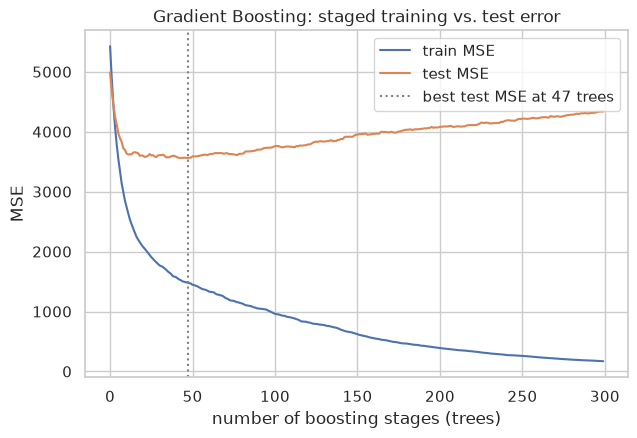

In [12]:
# Watch training and test error fall (and possibly overfit) as more trees are added
train_errors = list(gb_model.staged_predict(X_train))
test_errors = list(gb_model.staged_predict(X_test))
train_mse = [mean_squared_error(y_train, p) for p in train_errors]
test_mse = [mean_squared_error(y_test, p) for p in test_errors]

plt.figure(figsize=(7, 4.5))
plt.plot(train_mse, label="train MSE")
plt.plot(test_mse, label="test MSE")
best_iter = int(np.argmin(test_mse))
plt.axvline(best_iter, color="gray", linestyle=":", label=f"best test MSE at {best_iter} trees")
plt.xlabel("number of boosting stages (trees)")
plt.ylabel("MSE")
plt.title("Gradient Boosting: staged training vs. test error")
plt.legend()
plt.show()

Training error keeps dropping the longer boosting runs, but test error
bottoms out and can creep back up — this is why `n_estimators` (or early
stopping) is a hyperparameter worth tuning, covered in
`06_model_selection_tuning`.

## 7. Support Vector Regression (SVR)

**Theory.** SVR fits a function such that most points fall within an
`epsilon`-wide margin ("tube") around it, only penalizing points outside the
tube. With a non-linear **kernel** (e.g., RBF), it can capture curved
relationships without explicit polynomial features. Sensitive to feature
scaling, so we standardize first.

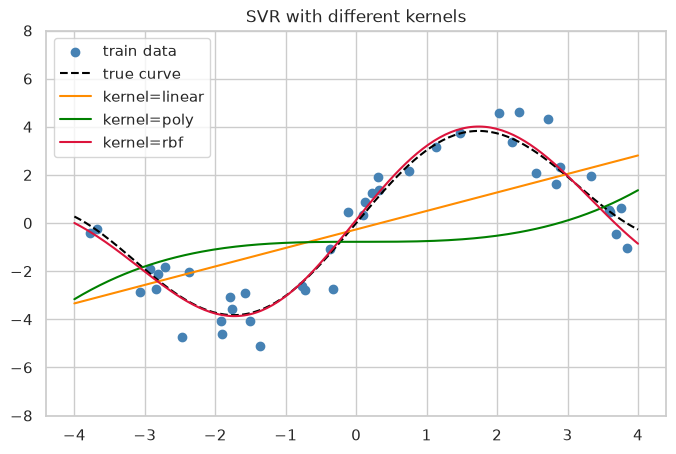

In [13]:
from sklearn.svm import SVR

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(x_1d_train, y_1d_train, label="train data", color="steelblue")
ax.plot(x_plot, true_curve(x_plot), color="black", linestyle="--", label="true curve")

x_1d_scaler = StandardScaler().fit(x_1d_train.reshape(-1, 1))
x_1d_train_s = x_1d_scaler.transform(x_1d_train.reshape(-1, 1))
x_plot_s = x_1d_scaler.transform(x_plot.reshape(-1, 1))

for kernel, color in zip(["linear", "poly", "rbf"], ["darkorange", "green", "crimson"]):
    svr = SVR(kernel=kernel, C=10, epsilon=0.3)
    svr.fit(x_1d_train_s, y_1d_train)
    ax.plot(x_plot, svr.predict(x_plot_s), color=color, label=f"kernel={kernel}")

ax.set_ylim(-8, 8)
ax.legend()
ax.set_title("SVR with different kernels")
plt.show()

In [14]:
svr_model, svr_pred = evaluate("SVR (RBF kernel)", SVR(kernel="rbf", C=10), X_train_s, X_test_s)

      SVR (RBF kernel):  RMSE =  56.50   R2 = 0.401


## 8. Model Comparison

Putting every model's test-set performance side by side, on the same
diabetes train/test split.

,RMSE,R2
Linear Regression,54.704490,0.438432
Ridge (alpha=1.0),54.810792,0.436247
Lasso (alpha=0.1),54.859481,0.435245
ElasticNet (alpha=0.1),55.019063,0.431955
SVR (RBF kernel),56.495974,0.401048
Random Forest,61.073556,0.300056
Gradient Boosting,65.854446,0.186183
Decision Tree (depth=4),70.359225,0.071036


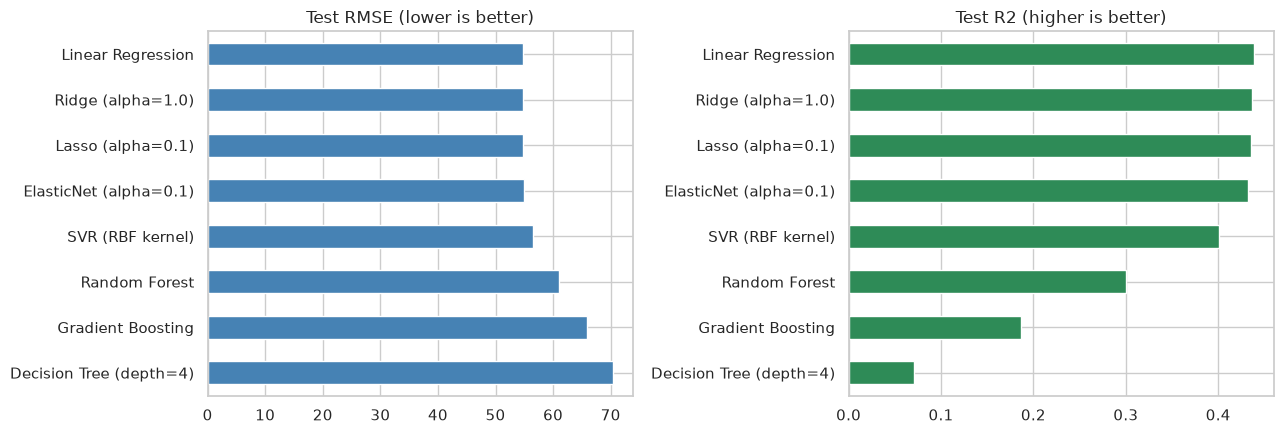

In [15]:
comparison = pd.DataFrame(results, index=["RMSE", "R2"]).T.sort_values("RMSE")
display(comparison)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
comparison["RMSE"].plot.barh(ax=axes[0], color="steelblue")
axes[0].set_title("Test RMSE (lower is better)")
axes[0].invert_yaxis()

comparison["R2"].plot.barh(ax=axes[1], color="seagreen")
axes[1].set_title("Test R2 (higher is better)")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

No single algorithm wins every dataset — this is the essence of the "no free
lunch" idea in ML. What matters is having a consistent, fair comparison
workflow (same split, same metrics), which is exactly the pattern
`06_model_selection_tuning` extends with proper cross-validation and
hyperparameter search.

## Exercises

1. Tune the `alpha` in Ridge/Lasso above (try `0.01`, `1`, `10`, `100`) — at what point does performance start to degrade?
2. Increase `n_estimators` for the Random Forest to 1000 — does test RMSE keep improving, or plateau?
3. Try `SVR(kernel="rbf", C=1)` vs. `C=100` on the diabetes data — how does `C` affect the fit?

## Key Takeaways

- Linear models are interpretable but assume linearity; polynomial features and kernels are two different ways to add curvature.
- Ridge/Lasso/ElasticNet trade a bit of bias for much lower variance — Lasso additionally performs feature selection.
- Tree ensembles (Random Forest, Gradient Boosting) usually give the best out-of-the-box accuracy on tabular data with minimal preprocessing.
- Always compare candidate models on the **same** held-out data with the **same** metrics before picking a winner.